/tmp/ipykernel_9473/2496952780.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date = pd.date_range(start="1949-01", periods=len(data), freq="M")


NameError: name 'mdates' is not defined

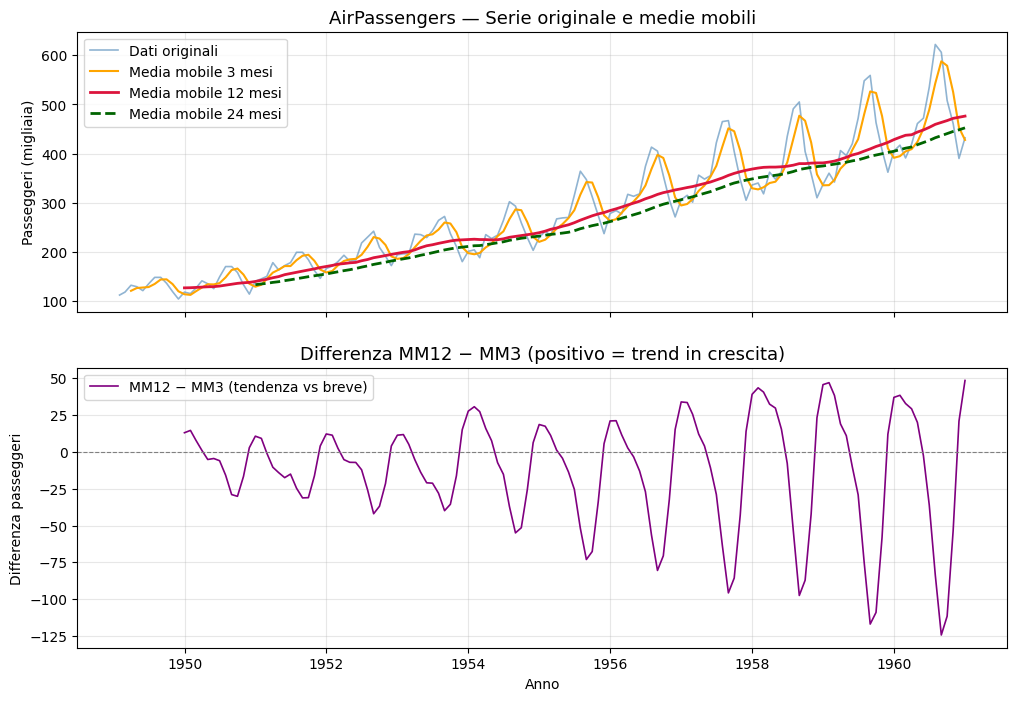

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from statsmodels.tsa.seasonal import seasonal_decompose

# =========================
# 1. CARICAMENTO DATASET
# =========================
data = get_rdataset("AirPassengers").data

# Costruzione serie temporale
# Creare le date
date = pd.date_range(start="1949-01", periods=len(data), freq="M")
df = pd.DataFrame({
    "date": date,
    "value": data["value"]
})
df.set_index("date", inplace=True)

# =========================
# 2. CALCOLO MEDIA MOBILE
# =========================

# Media mobile semplice a 12 mesi (1 anno -> elimina stagionalità)
df["MM_12"] = df["value"].rolling(window=12).mean() # --> roling(window=N).mean(): calcola la media delgi ultimi N valori per ogni punto.
                                                    #     Più grande è la finestra, più liscia risulta la curva
# Media mobile semplice a 3 mesi (breve termine)
df["MM_3"] = df["value"].rolling(window=3).mean()

# Media mobile semplice a 24 mesi (lungo termine)
df["MM_24"] = df["value"].rolling(window=24).mean()

# =========================
# 3. VISUALIZZAZIONE
# =========================
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Grafico superiore: serie originale + medie mobili ---
ax1 = axes[0]
ax1.plot(df.index, df["value"],
         color="steelblue", linewidth=1.2, alpha=0.6, label="Dati originali")
ax1.plot(df.index, df["MM_3"],
         color="orange", linewidth=1.5, label="Media mobile 3 mesi")
ax1.plot(df.index, df["MM_12"],
         color="crimson", linewidth=2, label="Media mobile 12 mesi")
ax1.plot(df.index, df["MM_24"],
         color="darkgreen", linewidth=2, linestyle="--", label="Media mobile 24 mesi")

ax1.set_title("AirPassengers — Serie originale e medie mobili", fontsize=13)
ax1.set_ylabel("Passeggeri (migliaia)")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# --- Grafico inferiore: confronto MM12 vs MM3 (smoothing) ---
ax2 = axes[1]
ax2.plot(df.index, df["MM_12"] - df["MM_3"],
         color="purple", linewidth=1.2, label="MM12 − MM3 (tendenza vs breve)")
ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax2.set_title("Differenza MM12 − MM3 (positivo = trend in crescita)", fontsize=13)
ax2.set_ylabel("Differenza passeggeri")
ax2.set_xlabel("Anno")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 4. STAMPA VALORI FINALI
# =========================
print("\n-- Ultimi 6 valori con medie mobili --")
print(df[["value", "MM_3", "MM_12", "MM_24"]].tail(6).round(1))


-- Ultimi 6 valori con medie mobili --
            value   MM_3  MM_12  MM_24
date                                  
1960-07-31    622  543.0  459.4  432.2
1960-08-31    606  587.7  463.3  436.4
1960-09-30    508  578.7  467.1  440.7
1960-10-31    461  525.0  471.6  445.0
1960-11-30    390  453.0  473.9  448.3
1960-12-31    432  427.7  476.2  452.2
